## PINN for the Helmholtz inverse problem

In [31]:
import jax
import jax.numpy as jnp
import functools
import numpy as np
import optax
import matplotlib.pyplot as plt
from data_load import WaveguideBoundaryData

In [32]:
print(jax.devices())

[CudaDevice(id=0)]


**Data loading**

In [33]:
#Domain Omega : [-1,1]x[0,0.6]
#conditions de neuman en y=0 et y=0.6
H = 0.6
L = 1

data_loader_left = WaveguideBoundaryData('data/pinn_boundary_left_barrehalf_contrast20percent_mode0.csv')
data_loader_right = WaveguideBoundaryData('data/pinn_boundary_right_barrehalf_contrast20percent_mode0.csv')

X_left, Y_left, U_re_left, U_im_left, freq = data_loader_left.get_training_data()
X_right, Y_right, U_re_right, U_im_right, _ = data_loader_right.get_training_data()

Y_left = Y_left[freq[0]]
Y_right = Y_right[freq[0]]

**Normalisation**

In [34]:
# x is already in [-1,1]
#y and u [-1,1]

Y_norm = jnp.max(Y_left)
Y_left=2*Y_left/Y_norm - 1
Y_right=2*Y_right/Y_norm - 1

U_norm = {}
U_left_norm = {}
U_right_norm = {}

for f in freq:
    U_norm[f] = np.sqrt(jnp.max(np.concatenate((U_re_left[f]**2 + U_im_left[f]**2,U_re_right[f]**2 + U_im_right[f]**2))))
    U_re_left[f]/=U_norm[f]
    U_im_left[f]/=U_norm[f]
    U_re_right[f]/=U_norm[f]
    U_im_right[f]/=U_norm[f]
    U_left_norm[f] = jnp.stack([U_re_left[f],U_im_left[f]], axis=1)
    U_right_norm[f] = jnp.stack([U_re_right[f],U_im_right[f]], axis=1)

**Initialization**

In [35]:
key = jax.random.key(0)

c0 = 340
cmax = 1.5 * c0
cmin = 0.5 * c0

msq_min = 1.0 / (cmax**2)
msq_max = 1.0 / (cmin**2)

fmax = jnp.max(freq)
N_modes = int(jnp.round(2*H*fmax/c0)) + 5
contrast = 1

m = 64

key, subkey = jax.random.split(key)

B_base = jax.random.normal(subkey, (m, 2))

def gamma(x, y, sigma):
    x_phys = x * L 
    y_phys = (y + 1.0) * H / 2.0
    v_phys = jnp.array([x_phys, y_phys])
    B = B_base * sigma
    return jnp.concatenate([jnp.cos(B@v_phys),jnp.sin(B@v_phys)])

n_gauss_legendre = 20

y_gauss_legendre, w_gauss_legendre = np.polynomial.legendre.leggauss(n_gauss_legendre)

n_input = 2
n_layers_uv = [2*m, 64, 64, 64, 64, 2]
n_layers_m = [n_input, 64, 64, 1]

#Xavier init

def init_layers(key, n_layers):
    layers = []
    keys = jax.random.split(key, len(n_layers) - 1)
    
    for i, k in enumerate(keys):
        W = jax.random.normal(k, (n_layers[i], n_layers[i+1])) * jnp.sqrt(2.0 / (n_layers[i] + n_layers[i+1]))
        b = jnp.zeros(n_layers[i+1])
        layers.append({"W": W, "b": b})
    return layers

def init_layers_uv(key, n_layers, f_val, mode_val):
    kx = 2 * jnp.pi * f_val / (contrast * c0)
    ky = mode_val * jnp.pi / H
    
    layers_uv = init_layers(key, n_layers)
    return {'layers': layers_uv, 'sigma': jnp.array([kx, ky])}

key, subkey_m = jax.random.split(key)
layers_m = init_layers(subkey_m, n_layers_m)
layers_m[-1]["b"] = -jnp.log(27.0 / 5.0)
layers_m[-1]["W"] /= 10.0

params_uv = {}

for f in freq:
    key, subkey_f = jax.random.split(key)
    params_uv[float(f)] = init_layers_uv(subkey_f, n_layers_uv, f, 0)

**The Forward pass**

In [36]:
def forward_func(layers,X):
    n = len(layers)
    Z = X
    for i in range(n-1):
        Z = jax.nn.tanh(Z @ layers[i]["W"] + layers[i]["b"])
    Z = Z @ layers[-1]["W"] + layers[-1]["b"]
    return Z
 
def forward_params(layers,X):
    n = len(layers)
    Z = X
    for i in range(n-1):
        Z = jax.nn.tanh(Z @ layers[i]["W"] + layers[i]["b"])
    Z = msq_min + (msq_max-msq_min) * jax.nn.sigmoid(Z @ layers[-1]["W"] + layers[-1]["b"])
    return Z.squeeze()

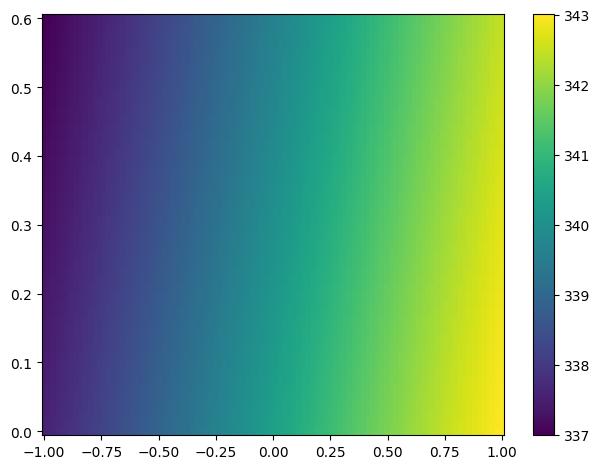

In [37]:
def c(x,y):
    return 1/jnp.sqrt(forward_params(layers_m, jnp.array([x, y])))

x = np.linspace(-1,1,100)
y = np.linspace(0,0.6,50)

c_grid = jax.vmap(jax.vmap(c, in_axes=(0, None)), in_axes=(None, 0))(x,2*y/H-1)

plt.pcolormesh(x, y, c_grid)
plt.colorbar()
plt.tight_layout()
plt.show()

**The loss function**

In [38]:
y_quad = (y_gauss_legendre + 1.0) * H / 2.0
w_quad = w_gauss_legendre * H / 2.0
n_modes = jnp.arange(N_modes)
a_n = jnp.sqrt(2/H) * jnp.ones(N_modes)
a_n = a_n.at[0].set(jnp.sqrt(1/H))
C_quad = a_n[:, None] * jnp.cos(n_modes[:, None] * jnp.pi * y_quad[None, :] / H)

def loss_fn(params_uv, layers_m, x, y, f, target_u_left, target_u_right, y_bnd_left, y_bnd_right, u_norm_val, weights, is_warmup=False, use_healthy_guide=False):

    def uv(x,y):
        features = gamma(x, y, params_uv['sigma'])
        return forward_func(params_uv['layers'], features)
    
    def m(x,y):
        return forward_params(layers_m, jnp.array([x, y]))
    
    def k2(x,y):
        if use_healthy_guide:
            return (2*jnp.pi*f/c0)**2
        else:
            return (2*jnp.pi*f)**2*m(x,y)
    
    def uv_x(x, y):
        return jax.jacfwd(uv, argnums=0)(x, y)/L
    
    def uv_y(x, y):
        return jax.jacfwd(uv, argnums=1)(x, y)*(2/H)
    
    def m_x(x,y):
        return jax.grad(m, argnums=0)(x, y)/L
    
    def m_y(x,y):
        return jax.grad(m, argnums=1)(x, y)*(2/H)

    def pde_residual(x, y):
        uv_xx = jax.jacfwd(jax.jacfwd(uv, argnums=0), argnums=0)(x, y) / L**2
        uv_yy = jax.jacfwd(jax.jacfwd(uv, argnums=1), argnums=1)(x, y)*(2/H)**2
        return uv_xx + uv_yy + k2(x,y)*uv(x,y)
    
    k0 = 2*jnp.pi*f/c0
    beta_n = jnp.sqrt(k0**2 - (n_modes*jnp.pi/H)**2 +0j)
    
    def compute_dtn_loss(x_bnd, y_data, sign, A_inc=None):
        uv_quad = jax.vmap(uv, in_axes=(None, 0))(x_bnd, y_gauss_legendre)
        U_quad_complex = uv_quad[:, 0] + 1j * uv_quad[:, 1]
        
        u_n = C_quad @ (w_quad * U_quad_complex)
        
        dtn_n = sign * 1j * beta_n * u_n
        if A_inc is not None:
            dtn_n = dtn_n + 2j * beta_n * A_inc
        
        def DtN_eval(y_eval):
            C_y = a_n * jnp.cos(n_modes * jnp.pi * (y_eval+1)/2)
            return C_y @ dtn_n
            
        dtn_pred_complex = jax.vmap(DtN_eval)(y_data)
        
        dtn_actual = jax.vmap(uv_x, in_axes=(None, 0))(x_bnd, y_data)
        dtn_actual_complex = dtn_actual[:, 0] + 1j * dtn_actual[:, 1]
        
        return jnp.mean(jnp.abs(dtn_pred_complex - dtn_actual_complex)**2)

    A_inc_left = jnp.zeros(N_modes, dtype=jnp.complex64)
    amplitude_incidente = jnp.exp(-1j * beta_n[0] * L) / u_norm_val
    A_inc_left = A_inc_left.at[0].set(amplitude_incidente)
    #residual
    vmap_pde_residual = jax.vmap(pde_residual, in_axes=(0, 0))
    pde_loss = jnp.mean(vmap_pde_residual(x, y)**2)
    #boundary conditions
    dtn_loss_left = compute_dtn_loss(-1.0, y, sign=-1, A_inc=A_inc_left)
    dtn_loss_right = compute_dtn_loss(1.0, y, sign=1, A_inc=None)
    neum_loss = jnp.mean(jax.vmap(uv_y, in_axes=(0, None))(x, 1.0)**2 + jax.vmap(uv_y, in_axes=(0, None))(x, -1.0)**2)
    bc_loss = neum_loss + dtn_loss_left + dtn_loss_right
    #data + TV
    if is_warmup:
        data_loss = 0.0
    else:
        vmap_uv_y = jax.vmap(uv, (None,0))
        data_loss = jnp.mean((vmap_uv_y(-1.0,y_bnd_left) - target_u_left)**2)+jnp.mean((vmap_uv_y(1.0,y_bnd_right) - target_u_right)**2)
        

    total_loss = weights[0]*pde_loss + weights[1]*bc_loss + weights[2]*data_loss
    
    return total_loss, (pde_loss, bc_loss, data_loss)

**Le training**

In [ ]:
lr_uv = 1e-3
lr_m = 3e-4
lr_sigma = 1e-2

def make_train_step_forward(adam_opt, lbfgs_opt):

    @functools.partial(jax.jit, static_argnames=('use_lbfgs', 'use_healthy_guide'))
    def train_step_forward(params_uv, layers_m, opt_state_uv, x, y, f_val, target_left, target_right, y_bnd_left, y_bnd_right, u_norm, current_weights, use_lbfgs=False, use_healthy_guide=True):
        def loss_uv(p_uv):
            return loss_fn(p_uv, layers_m, x, y, f_val, target_left, target_right,
                y_bnd_left, y_bnd_right, u_norm, current_weights, is_warmup=True, use_healthy_guide=use_healthy_guide)

        (loss, aux), grads_uv = jax.value_and_grad(loss_uv, has_aux=True)(params_uv)

        if use_lbfgs:
            def value_fn(p_uv):
                v, _ = loss_uv(p_uv)
                return v
            updates_uv, opt_state_uv = lbfgs_opt.update(
                grads_uv, opt_state_uv, params_uv,
                value=loss, grad=grads_uv, value_fn=value_fn)
        else:
            updates_uv, opt_state_uv = adam_opt.update(grads_uv, opt_state_uv, params_uv)

        params_uv = optax.apply_updates(params_uv, updates_uv)
        return params_uv, opt_state_uv, loss, aux

    return train_step_forward


def make_train_step_inverse(adam_opt_uv, adam_opt_m, lbfgs_opt_packed):

    @functools.partial(jax.jit, static_argnames=('use_lbfgs',))
    def train_step_inverse(params_uv, layers_m, opt_state_uv, opt_state_m, opt_state_lbfgs, x, y, f_val, target_left, target_right, y_bnd_left, y_bnd_right, u_norm, current_weights, use_lbfgs=False):
        
        def loss_full(p_uv, l_m):
            return loss_fn(p_uv, l_m, x, y, f_val, target_left, target_right,
                y_bnd_left, y_bnd_right, u_norm, current_weights, is_warmup=False, use_healthy_guide=False)
        
        (loss, aux), (grads_uv, grads_m) = jax.value_and_grad(loss_full, argnums=(0,1), has_aux=True)(params_uv, layers_m)

        if use_lbfgs:
            params_packed = {'uv': params_uv, 'm': layers_m}
            grads_packed = {'uv': grads_uv, 'm': grads_m}
            
            def value_fn_packed(p_packed):
                v, _ = loss_full(p_packed['uv'], p_packed['m'])
                return v

            updates_packed, opt_state_lbfgs = lbfgs_opt_packed.update(
                grads_packed, opt_state_lbfgs, params_packed,
                value=loss, grad=grads_packed, value_fn=value_fn_packed)
            
            params_packed = optax.apply_updates(params_packed, updates_packed)
            params_uv = params_packed['uv']
            layers_m = params_packed['m']
        else:
            updates_uv, opt_state_uv = adam_opt_uv.update(grads_uv, opt_state_uv, params_uv)
            params_uv = optax.apply_updates(params_uv, updates_uv)

            updates_m, opt_state_m = adam_opt_m.update(grads_m, opt_state_m, layers_m)
            layers_m = optax.apply_updates(layers_m, updates_m)

        return params_uv, layers_m, opt_state_uv, opt_state_m, opt_state_lbfgs, loss, aux

    return train_step_inverse


# --- Convergence criterion ---

def check_switch_criterion(loss_history, window=10, threshold=1e-3):
    """Returns True if the relative slope of the loss is below threshold."""
    if len(loss_history) < window:
        return False
    old_loss = loss_history[-window]
    new_loss = loss_history[-1]
    relative_slope = abs(new_loss - old_loss) / max(abs(old_loss), 1e-12)
    return relative_slope < threshold and jnp.mean(old_loss) < 1e-1


# --- Main training function ---

def train(params_uv, layers_m, N,
          max_steps_adam_phase1, max_steps_lbfgs_phase1,
          max_steps_adam_phase2, max_steps_lbfgs_phase2,
          freqs, eval_interval, switch_threshold, switch_window, key):

    loss_forward = []
    loss_inverse = []

    weights_phase1 = jnp.array([1.0, 10.0, 0.0])

    best_params_uv = params_uv

    for i, freq in enumerate(freqs):
        print(f"\n{'='*60}")
        print(f"--- f = {freq} Hz ---")
        print(f"{'='*60}")

        param_uv = params_uv[freq]
        best_params_uv[freq] = param_uv
        best_params_m = layers_m
        best_loss = float('inf')

        use_healthy_guide_flag = (i == 0)

        if i > 0:
            scale = jnp.abs(best_params_uv[freqs[i-1]]["sigma"][1]/best_params_uv[freqs[i-1]]["sigma"][0])
            sigma_x = param_uv["sigma"][0]
            param_uv["sigma"] = param_uv["sigma"].at[1].set(scale*sigma_x)

        # ============================================================
        # PHASE 1: Forward (only param_uv)
        # ============================================================

        print(f"\n--- Phase 1: Adam (max {max_steps_adam_phase1} steps) ---")

        cosine_p1 = optax.schedules.cosine_decay_schedule(
            init_value=lr_uv, decay_steps=max_steps_adam_phase1, alpha=0.1)
        
        cosine_sigma_p1 = optax.schedules.cosine_decay_schedule(
            init_value=lr_sigma, decay_steps=max_steps_adam_phase1, alpha=0.1)

        adam_base_p1 = optax.chain(
            optax.clip_by_global_norm(1.0),
            optax.scale_by_adam(),
            optax.scale_by_schedule(cosine_p1),
            optax.scale(-1.0))
        
        adam_sigma_p1 = optax.chain(
            optax.clip_by_global_norm(1.0),
            optax.scale_by_adam(),
            optax.scale_by_schedule(cosine_sigma_p1),
            optax.scale(-1.0))

        param_labels_p1 = jax.tree_util.tree_map(lambda _: 'base', param_uv)
        if "sigma" in param_labels_p1:
            param_labels_p1["sigma"] = jax.tree_util.tree_map(lambda _: 'sigma', param_uv["sigma"])

        adam_uv_p1 = optax.multi_transform(
            transforms={'base': adam_base_p1, 'sigma': adam_sigma_p1},
            param_labels=param_labels_p1
        )
        lbfgs_uv_p1 = optax.lbfgs()

        step_forward = make_train_step_forward(adam_uv_p1, lbfgs_uv_p1)
        opt_state_uv = adam_uv_p1.init(param_uv)

        loss_history_p1 = []
        switched_to_lbfgs = False

        for step in range(max_steps_adam_phase1):
            key, subkey1, subkey2 = jax.random.split(key, 3)
            x = jax.random.uniform(subkey1, (N,), minval=-1, maxval=1)
            y = jax.random.uniform(subkey2, (N,), minval=-1, maxval=1)

            param_uv, opt_state_uv, loss, aux = step_forward(
                param_uv, layers_m, opt_state_uv, x, y, freq,
                U_left_norm[freq], U_right_norm[freq],
                Y_left, Y_right, U_norm[freq], weights_phase1,
                use_lbfgs=False, use_healthy_guide=use_healthy_guide_flag)

            loss_history_p1.append(float(loss))

            if step % eval_interval == 0:
                pde_loss, bc_loss, _ = aux
                loss_forward.append((pde_loss, bc_loss))
                print(f"[Adam] Step {step} | pde {pde_loss:.2e} | bc {bc_loss:.2e} | total {loss:.2e} | scales {param_uv['sigma']}")
                if loss < best_loss:
                    best_loss = loss
                    best_params_uv[freq] = param_uv

            if check_switch_criterion(loss_history_p1, window=switch_window, threshold=switch_threshold):
                print(f"[Adam] Convergence criterion met at step {step}. Switching to L-BFGS.")
                switched_to_lbfgs = True
                param_uv = best_params_uv[freq]
                break

        # --- Phase 1: L-BFGS ---
        if switched_to_lbfgs or max_steps_lbfgs_phase1 > 0:
            print(f"\n--- Phase 1: L-BFGS (max {max_steps_lbfgs_phase1} steps) ---")
            opt_state_uv = lbfgs_uv_p1.init(param_uv)
            key, subkey1, subkey2 = jax.random.split(key, 3)
            x_lbfgs = jax.random.uniform(subkey1, (N,), minval=-1, maxval=1)
            y_lbfgs = jax.random.uniform(subkey2, (N,), minval=-1, maxval=1)

            for step in range(max_steps_lbfgs_phase1):
                param_uv, opt_state_uv, loss, aux = step_forward(
                    param_uv, layers_m, opt_state_uv, x_lbfgs, y_lbfgs, freq,
                    U_left_norm[freq], U_right_norm[freq],
                    Y_left, Y_right, U_norm[freq], weights_phase1,
                    use_lbfgs=True, use_healthy_guide=use_healthy_guide_flag)

                if step % eval_interval == 0:
                    pde_loss, bc_loss, _ = aux
                    loss_forward.append((pde_loss, bc_loss))
                    print(f"[LBFGS] Step {step} | pde {pde_loss:.2e} | bc {bc_loss:.2e} | total {loss:.2e} | scales {param_uv['sigma']}")
                    if loss < best_loss:
                        best_loss = loss
                        best_params_uv[freq] = param_uv

        # ============================================================
        # PHASE 2: Inverse (param_uv + layers_m)
        # ============================================================

        best_loss = float('inf')
        
        if max_steps_adam_phase2 > 0 or max_steps_lbfgs_phase2 > 0:

            print(f"\n--- Phase 2: Adam (max {max_steps_adam_phase2} steps) ---")

            cosine_uv_p2 = optax.schedules.cosine_decay_schedule(
                init_value=lr_uv, decay_steps=max_steps_adam_phase2, alpha=0.1)
            cosine_sigma_p2 = optax.schedules.cosine_decay_schedule(
                init_value=lr_sigma, decay_steps=max_steps_adam_phase2//3, alpha=0.1)
            
            cosine_m_p2 = optax.schedules.cosine_decay_schedule(
                init_value=lr_m, decay_steps=max_steps_adam_phase2, alpha=0.1)

            adam_base_p2 = optax.chain(
                optax.clip_by_global_norm(1.0),
                optax.scale_by_adam(),
                optax.scale_by_schedule(cosine_uv_p2),
                optax.scale(-1.0))

            adam_sigma_p2 = optax.chain(
                optax.clip_by_global_norm(1.0),
                optax.scale_by_adam(),
                optax.scale_by_schedule(cosine_sigma_p2),
                optax.scale(-1.0))

            param_labels_p2 = jax.tree_util.tree_map(lambda _: 'base', param_uv)
            if "sigma" in param_labels_p2:
                param_labels_p2["sigma"] = jax.tree_util.tree_map(lambda _: 'sigma', param_uv["sigma"])

            adam_uv_p2 = optax.multi_transform(
                transforms={'base': adam_base_p2, 'sigma': adam_sigma_p2},
                param_labels=param_labels_p2
            )

            adam_m_p2 = optax.chain(
                optax.clip_by_global_norm(1.0),
                optax.scale_by_adam(),
                optax.scale_by_schedule(cosine_m_p2),
                optax.scale(-1.0))
            
            lbfgs_packed_p2 = optax.lbfgs()

            step_inverse = make_train_step_inverse(adam_uv_p2, adam_m_p2, lbfgs_packed_p2)

            opt_state_uv = adam_uv_p2.init(param_uv)
            opt_state_m = adam_m_p2.init(layers_m)
            opt_state_lbfgs = None

            data_weight_schedule = optax.linear_schedule(
                init_value=0.1, end_value=10.0,
                transition_steps=max(max_steps_adam_phase2 // 3, 1))

            loss_history_p2 = []
            switched_to_lbfgs_p2 = False

            for step in range(max_steps_adam_phase2):
                weights_phase2 = jnp.array([1.0, 1.0, data_weight_schedule(step), 0.0])

                key, subkey1, subkey2 = jax.random.split(key, 3)
                x = jax.random.uniform(subkey1, (N,), minval=-1, maxval=1)
                y = jax.random.uniform(subkey2, (N,), minval=-1, maxval=1)

                param_uv, layers_m, opt_state_uv, opt_state_m, opt_state_lbfgs, loss, aux = step_inverse(
                    param_uv, layers_m, opt_state_uv, opt_state_m, opt_state_lbfgs, x, y, freq,
                    U_left_norm[freq], U_right_norm[freq],
                    Y_left, Y_right, U_norm[freq], weights_phase2,
                    use_lbfgs=False)

                loss_history_p2.append(float(loss))

                if step % eval_interval == 0:
                    pde_loss, bc_loss, data_loss = aux
                    loss_inverse.append((pde_loss, bc_loss, data_loss))
                    print(f"[Adam] Step {step} | pde {pde_loss:.2e} | bc {bc_loss:.2e} | data {data_loss:.2e} | total {loss:.2e} | scales {param_uv['sigma']}")
                    if loss < best_loss:
                        best_loss = loss
                        best_params_uv[freq] = param_uv
                        best_params_m = layers_m

                if check_switch_criterion(loss_history_p2, window=switch_window, threshold=switch_threshold):
                    print(f"[Adam] Convergence criterion met at step {step}. Switching to L-BFGS.")
                    switched_to_lbfgs_p2 = True
                    param_uv = best_params_uv[freq]
                    layers_m = best_params_m
                    break

            # --- Phase 2: L-BFGS ---
            if switched_to_lbfgs_p2 or max_steps_lbfgs_phase2 > 0:
                print(f"\n--- Phase 2: L-BFGS (max {max_steps_lbfgs_phase2} steps) ---")
                opt_state_lbfgs = lbfgs_packed_p2.init({'uv': param_uv, 'm': layers_m})
                weights_phase2_lbfgs = jnp.array([1.0, 1.0, 1.0])

                key, subkey1, subkey2 = jax.random.split(key, 3)
                x_lbfgs = jax.random.uniform(subkey1, (N,), minval=-1, maxval=1)
                y_lbfgs = jax.random.uniform(subkey2, (N,), minval=-1, maxval=1)

                for step in range(max_steps_lbfgs_phase2):
                    param_uv, layers_m, opt_state_uv, opt_state_m, opt_state_lbfgs, loss, aux = step_inverse(
                        param_uv, layers_m, opt_state_uv, opt_state_m, opt_state_lbfgs, x_lbfgs, y_lbfgs, freq,
                        U_left_norm[freq], U_right_norm[freq],
                        Y_left, Y_right, U_norm[freq], weights_phase2_lbfgs,
                        use_lbfgs=True)

                    if step % eval_interval == 0:
                        pde_loss, bc_loss, data_loss = aux
                        loss_inverse.append((pde_loss, bc_loss, data_loss))
                        print(f"[LBFGS] Step {step} | pde {pde_loss:.2e} | bc {bc_loss:.2e} | data {data_loss:.2e} | total {loss:.2e} | scales {param_uv['sigma']}")
                        if loss < best_loss:
                            best_loss = loss
                            best_params_uv[freq] = param_uv
                            best_params_m = layers_m

    return best_params_uv, best_params_m, key, loss_forward, loss_inverse

**La phase d'entrainement**

In [40]:
N = 1000
eval_interval = 200
switch_threshold = 0.0
switch_window = 10

max_steps_adam_phase1 = 20001
max_steps_lbfgs_phase1 = 5001
max_steps_adam_phase2 = 100001
max_steps_lbfgs_phase2 = 5001

freq = np.array([300.0])

key, subkey = jax.random.split(key)
params_uv, layers_m, key, loss_forward, loss_inverse = train(
    params_uv, layers_m, N,
    max_steps_adam_phase1, max_steps_lbfgs_phase1,
    max_steps_adam_phase2, max_steps_lbfgs_phase2,
    freq, eval_interval, switch_threshold, switch_window, key)


--- f = 300.0 Hz ---

--- Phase 1: Adam (max 20001 steps) ---
[Adam] Step 0 | pde 6.98e+02 | bc 3.45e+01 | total 1.04e+03 | scales [ 5.5339875  -0.00999993]
[Adam] Step 200 | pde 3.76e-01 | bc 1.08e-01 | total 1.46e+00 | scales [ 5.3678226e+00 -9.5618784e-04]
[Adam] Step 400 | pde 1.30e-01 | bc 5.49e-02 | total 6.79e-01 | scales [ 5.3205609e+00 -1.4466263e-05]
[Adam] Step 600 | pde 7.21e-01 | bc 2.19e-02 | total 9.41e-01 | scales [5.3179903  0.02172219]
[Adam] Step 800 | pde 4.31e-02 | bc 3.61e-02 | total 4.04e-01 | scales [ 5.3099184e+00 -9.2820928e-04]
[Adam] Step 1000 | pde 7.49e-02 | bc 4.25e-02 | total 5.00e-01 | scales [ 5.3011465e+00 -4.2566418e-04]
[Adam] Step 1200 | pde 8.16e-01 | bc 5.72e-02 | total 1.39e+00 | scales [5.32092    0.00566343]
[Adam] Step 1400 | pde 7.03e-02 | bc 2.97e-02 | total 3.68e-01 | scales [ 5.3216743  -0.00552381]
[Adam] Step 1600 | pde 4.08e-02 | bc 3.89e-02 | total 4.30e-01 | scales [5.2259607e+00 2.2450362e-04]
[Adam] Step 1800 | pde 3.17e-02 | bc 2

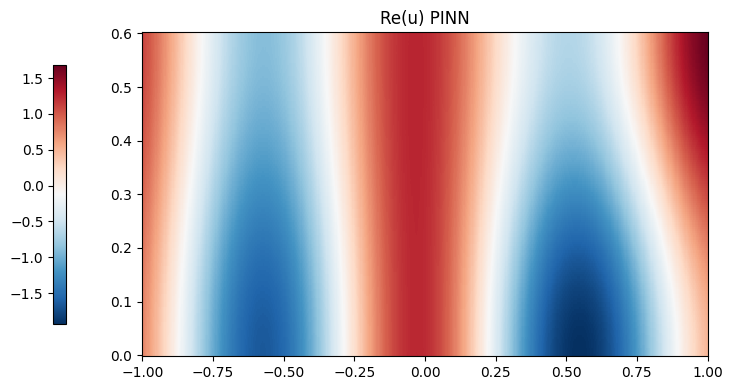

In [41]:
for f in freq:
    def u_real(x,y):
        features = gamma(x, y, params_uv[f]['sigma'])
        return forward_func(params_uv[f]['layers'], features)[0] * U_norm[f]

    x = np.linspace(-1, 1, 500)
    y = np.linspace(0, 0.6, 150)

    u_grid = jax.vmap(jax.vmap(u_real, in_axes=(0, None)), in_axes=(None, 0))(x, 2*y/H - 1)

    fig, ax = plt.subplots(figsize=(8, 4))

    pcm = ax.pcolormesh(x, y, u_grid, cmap='RdBu_r', rasterized=True)

    ax.set_title('Re(u) PINN')

    fig.colorbar(pcm, ax=ax, shrink=0.8, location='left')
    plt.tight_layout()
    #plt.savefig('fig/2D_WG_PINN_forward.pdf', dpi=300, bbox_inches='tight')
    plt.show()

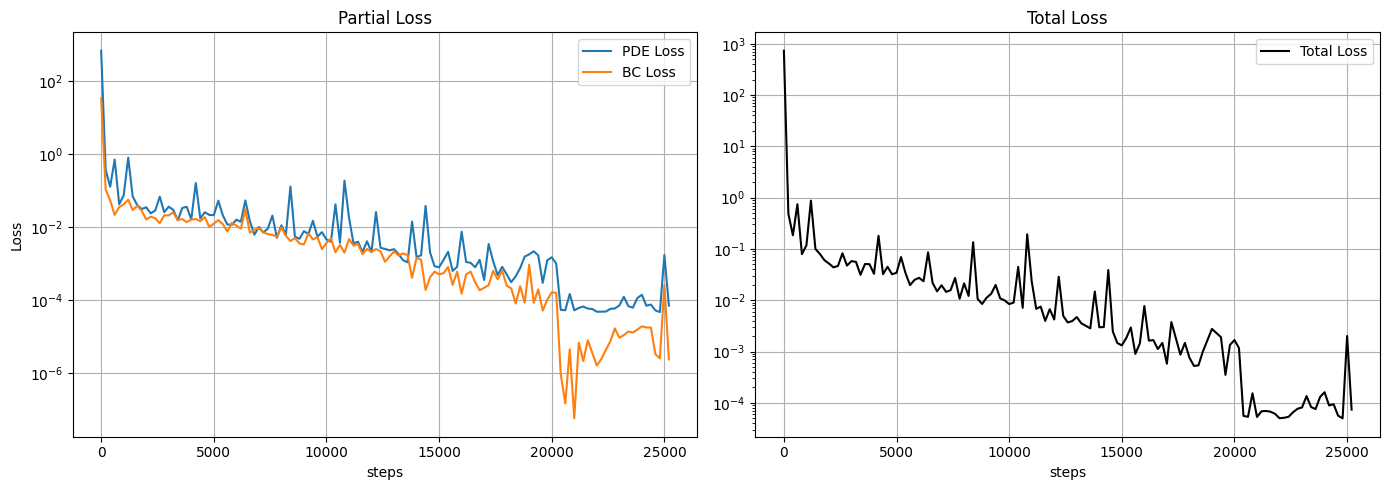

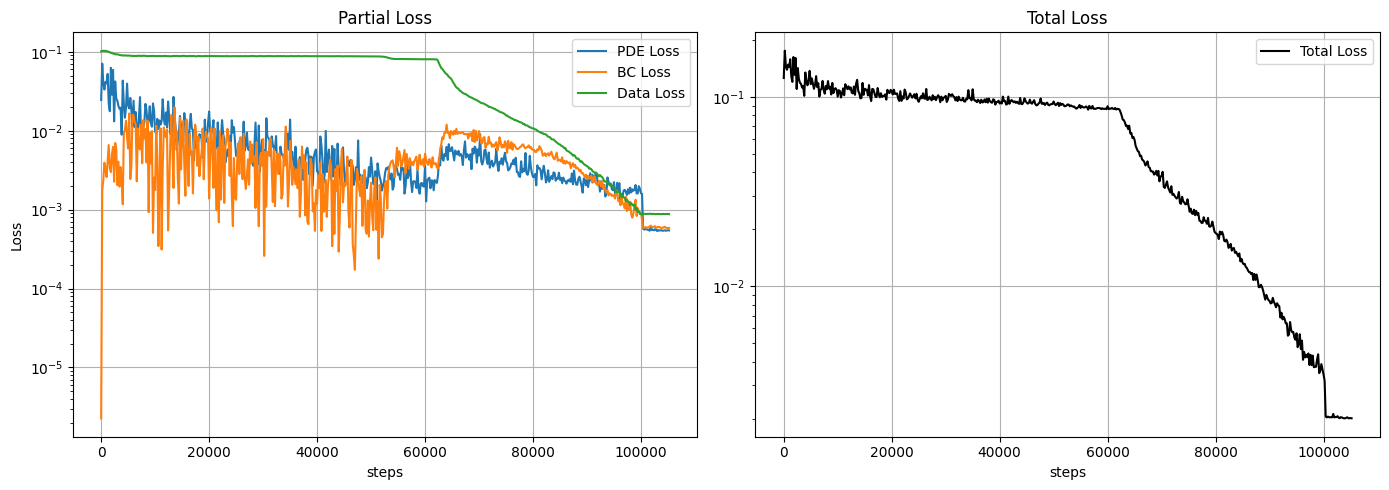

In [42]:
loss_forward_arr = np.array(loss_forward)
pde_losses = loss_forward_arr[:, 0]
bc_losses = loss_forward_arr[:, 1]
total_losses = pde_losses + bc_losses

eval_interval_plot = eval_interval

x_axis = eval_interval_plot * np.arange(len(loss_forward))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.semilogy(x_axis, pde_losses, label="PDE Loss")
ax1.semilogy(x_axis, bc_losses, label="BC Loss")

ax2.semilogy(x_axis, total_losses, label="Total Loss", color='black')

ax1.set_title("Partial Loss")
ax1.set_xlabel("steps")
ax1.set_ylabel("Loss")
ax1.legend(loc="upper right")
ax1.grid(True)

ax2.set_title("Total Loss")
ax2.set_xlabel("steps")
ax2.legend(loc="upper right")
ax2.grid(True)

plt.tight_layout()
plt.show()

loss_inverse_arr = np.array(loss_inverse)
pde_losses = loss_inverse_arr[:,0]
bc_losses = loss_inverse_arr[:,1]
data_losses = loss_inverse_arr[:,2]
total_losses = pde_losses + bc_losses + data_losses

eval_interval_plot = eval_interval

x_axis = eval_interval_plot * np.arange(len(loss_inverse_arr))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.semilogy(x_axis, pde_losses, label="PDE Loss")
ax1.semilogy(x_axis, bc_losses, label="BC Loss")
ax1.semilogy(x_axis, data_losses, label="Data Loss")

ax2.semilogy(x_axis, total_losses, label="Total Loss", color='black')

ax1.set_title("Partial Loss")
ax1.set_xlabel("steps")
ax1.set_ylabel("Loss")
ax1.legend(loc="upper right")
ax1.grid(True)

ax2.set_title("Total Loss")
ax2.set_xlabel("steps")
ax2.legend(loc="upper right")
ax2.grid(True)

plt.tight_layout()
plt.savefig('fig/2D_Wave_guide_losses.pdf')
plt.show()

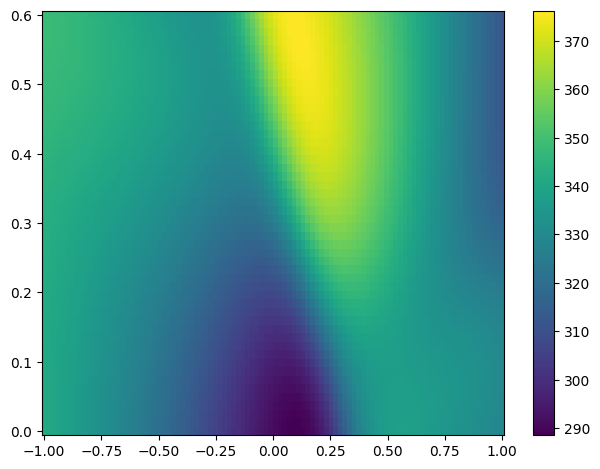

In [43]:
def c(x,y):
    return 1/jnp.sqrt(forward_params(layers_m, jnp.array([x, y])))

x = np.linspace(-1,1,100)
y = np.linspace(0,0.6,50)

c_grid = jax.vmap(jax.vmap(c, in_axes=(0, None)), in_axes=(None, 0))(x,2*y/H-1)

plt.pcolormesh(x, y, c_grid, rasterized=True)
plt.colorbar()
plt.tight_layout()
plt.savefig('fig/2D_Wave_guide_c_map_third.pdf')
plt.show()